# Modelling

In [ ]:
# =========================
# CORE / DATA HANDLING
# =========================
import numpy as np
import pandas as pd

# =========================
# COLAB / I/O
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/clean_amazon_reviews_text.csv")
df_feat = pd.read_csv("/content/drive/MyDrive/clean_amazon_reviews_feat.csv")


---
---
---
# Balancing the Data

In [ ]:
# Masks for each class
neg_mask = df["sentiment"] == "negative"
pos_mask = df["sentiment"] == "positive"

# Number of negatives (target size for positives)
n_neg = neg_mask.sum()

# Randomly sample positives to match the negatives
pos_sample_idx = df[pos_mask].sample(n=n_neg, random_state=42).index
neg_idx = df[neg_mask].index

# Indices to keep (balanced set)
keep_idx = neg_idx.union(pos_sample_idx)

# Apply to BOTH dataframes so they stay aligned
df = df.loc[keep_idx].reset_index(drop=True)
df_feat = df_feat.loc[keep_idx].reset_index(drop=True)

# Quick sanity check
print(df["sentiment"].value_counts())


sentiment
negative    35555
positive    35555
Name: count, dtype: int64


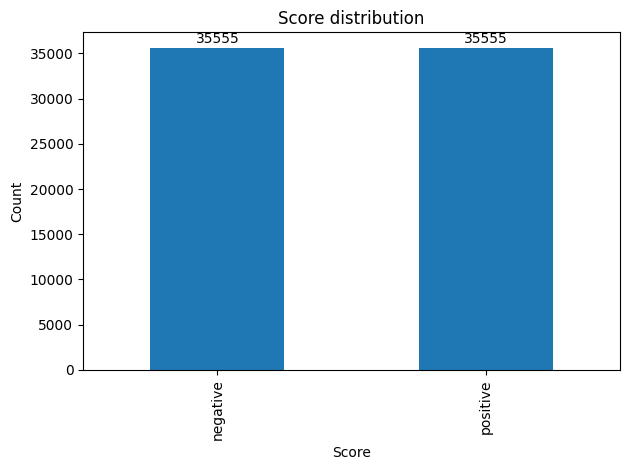

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

score_counts = df["sentiment"].value_counts().sort_index()
ax = score_counts.plot(kind="bar")
ax.set_title("Score distribution"); ax.set_xlabel("Score"); ax.set_ylabel("Count")
ax.bar_label(ax.containers[0], padding=2)
plt.tight_layout(); plt.show()

In [ ]:

print(df.shape)
print(df_feat.shape)

(71110, 2)
(71110, 4)


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71110 entries, 0 to 71109
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text_clean  71110 non-null  object
 1   sentiment   71110 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [ ]:
df_feat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71110 entries, 0 to 71109
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text_clean  71110 non-null  object
 1   sentiment   71110 non-null  object
 2   word_count  71110 non-null  int64 
 3   text_len    71110 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


---
---
---
# Helpers (functions for models)

In [ ]:
# Shared helpers for all models (evaluation, grids, saving)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

---
#### OOF generator: trains a clone per fold and returns OOF predictions/scores + per-fold macro-F1 ---

In [ ]:
def get_oof(estimator, X, y, cv, *, fit_kwargs=None, score_kind="proba"):
    """
    Build Out-Of-Fold (OOF) predictions for fair, leak-free evaluation.
    - estimator: a sklearn Pipeline (e.g., TF-IDF + classifier)
    - X, y: pandas Series/DataFrame
    - cv: a StratifiedKFold splitter
    - fit_kwargs: dict -> kwargs passed to .fit (e.g., {'clf__sample_weight': weights})
    - score_kind: 'proba' (predict_proba[:,1]) or 'decision' (decision_function)
    Returns: oof_pred (str labels), oof_score (float), fold_f1 (np.array of macro-F1 per fold)
    """
    oof_pred  = np.empty_like(y, dtype=object)
    oof_score = np.empty(len(y), dtype=float)
    fold_f1   = []

    for tr, te in cv.split(X, y):
        est = clone(estimator)
        kw  = fit_kwargs or {}
        est.fit(X.iloc[tr], y.iloc[tr], **kw)
        # test-fold outputs
        y_hat = est.predict(X.iloc[te])
        if score_kind == "proba":
            s = est.predict_proba(X.iloc[te])[:, 1]
        else:
            s = est.decision_function(X.iloc[te])

        oof_pred[te]  = y_hat
        oof_score[te] = s
        fold_f1.append(f1_score(y.iloc[te], y_hat, average="macro"))

    return oof_pred, oof_score, np.array(fold_f1)

---
#### Evaluation printer: report + CM + AUCs (PR-AUC for pos & neg)

In [ ]:
def eval_oof(y_true, y_pred, y_score, *, model_name="", score_kind="proba", cm_cmap="Blues"):
    """
    Prints classification_report, plots confusion matrix, and prints ROC-AUC + PR-AUC(pos/neg).
    score_kind controls how PR-AUC(neg) is computed: proba -> (1 - proba); decision -> (-score).
    Returns: dict of summary metrics.
    """
    print(f"\nOOF classification report — {model_name}\n")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=["negative","positive"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cm_cmap,
                xticklabels=["negative","positive"], yticklabels=["negative","positive"])
    plt.title(f"OOF Confusion Matrix — {model_name}")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

    y_pos = (y_true == "positive").astype(int)
    y_neg = (y_true == "negative").astype(int)

    roc = roc_auc_score(y_pos, y_score)
    pr_pos = average_precision_score(y_pos, y_score)
    neg_input = (1 - y_score) if score_kind == "proba" else (-y_score)
    pr_neg = average_precision_score(y_neg, neg_input)

    print(f"ROC-AUC (positive):  {roc:.4f}")
    print(f"PR-AUC  (positive): {pr_pos:.4f}")
    print(f"PR-AUC  (negative): {pr_neg:.4f}")

    return {"model": model_name, "roc_auc": roc, "pr_auc_pos": pr_pos, "pr_auc_neg": pr_neg}

---
#### GridSearch helper: small table out, best estimator back

In [ ]:
SCORER = make_scorer(f1_score, average="macro")

def run_grid(estimator, param_grid, X, y, *, cv, fit_kwargs=None, verbose=1):
    """
    Uniform grid search runner (macro-F1). Returns:
    (best_estimator, best_score, best_params, results_df)
    """
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="f1_macro",      # <- enforce macro-F1 (avoids pos_label=1 issue with string labels)
        cv=cv,
        n_jobs=-1,
        verbose=verbose,
        refit=True,
        error_score="raise"      # <- keep while fixing; remove later if you prefer NaNs
    )

    if fit_kwargs:
        gs.fit(X, y, **fit_kwargs)
    else:
        gs.fit(X, y)

    best = gs.best_estimator_
    res = (pd.DataFrame(gs.cv_results_)
           .sort_values("mean_test_score", ascending=False))
    view_cols = ["mean_test_score","std_test_score","mean_fit_time"] + \
                [c for c in res.columns if c.startswith("param_")]
    return best, gs.best_score_, gs.best_params_, res[view_cols].head(10)

---
#### Save helper

In [ ]:
import joblib
def save_model(estimator, path):
    joblib.dump(estimator, path)
    print("Saved:", path)

---
---
---
# Shared config, CV, and data bindings

In [ ]:
# Shared config, CV, and data bindings
RANDOM_STATE = 42

from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Expect these columns to exist from your EDA notebook
X = df["Text_clean"]
y = df["sentiment"]

# Common TF-IDF defaults applied across models for fairness
from sklearn.feature_extraction.text import TfidfVectorizer
TFIDF_DEFAULTS = dict(
    ngram_range=(1,2),
    max_features=10_000,  # you can set 20_000 later; start lean for speed
    min_df=5,
    sublinear_tf=True,
    stop_words="english"
)


---
---
---
# Models

---
### 1 -  TF-IDF + Logistic Regression

In [ ]:
# Logistic (TF-IDF + LogisticRegression) factory
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def make_logreg():
    return Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_DEFAULTS)),
        ("clf", LogisticRegression(
            class_weight="balanced",   # imbalance handled in loss
            solver="saga",             # fast & robust on sparse high-dim
            max_iter=300,
            n_jobs=1,                  # avoid nested parallelism
            random_state=RANDOM_STATE
        ))
    ])

CV macro-F1 (per-fold + mean±std)

In [ ]:
from sklearn.model_selection import cross_val_score

pipe_lr = make_logreg()

cv_scores = cross_val_score(
    pipe_lr, X, y, cv=cv, scoring="f1_macro", n_jobs=-1
)
print("CV macro-F1 per fold:", np.round(cv_scores, 4))
print("CV macro-F1 mean±std:", np.round(cv_scores.mean(), 4), "±", np.round(cv_scores.std(), 4))

CV macro-F1 per fold: [0.9149 0.9186 0.9172 0.9241 0.9156]
CV macro-F1 mean±std: 0.9181 ± 0.0033


OOF evaluation (report, CM heatmap, ROC-AUC, PR-AUC pos & neg)

OOF macro-F1 per fold (from OOF loop): [0.9149 0.9186 0.9172 0.9241 0.9156]
OOF macro-F1 mean±std: 0.9181 ± 0.0033

OOF classification report — Logistic (TF-IDF)

              precision    recall  f1-score   support

    negative     0.9185    0.9176    0.9180     35555
    positive     0.9177    0.9185    0.9181     35555

    accuracy                         0.9181     71110
   macro avg     0.9181    0.9181    0.9181     71110
weighted avg     0.9181    0.9181    0.9181     71110



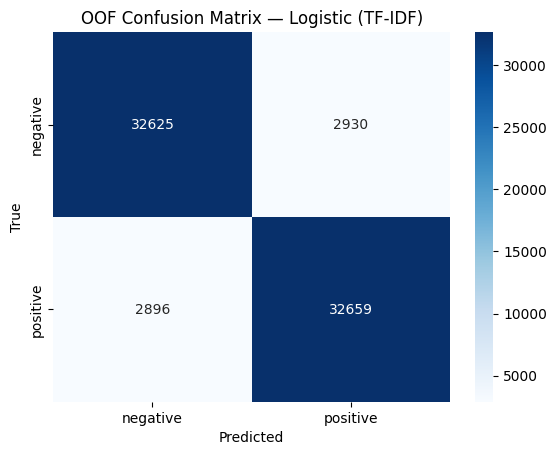

ROC-AUC (positive):  0.9737
PR-AUC  (positive): 0.9735
PR-AUC  (negative): 0.9736


In [ ]:
pipe_lr = make_logreg()

oof_pred, oof_score, fold_f1 = get_oof(
    pipe_lr, X, y, cv, score_kind="proba"   # Logistic has predict_proba
)

print("OOF macro-F1 per fold (from OOF loop):", np.round(fold_f1, 4))
print("OOF macro-F1 mean±std:", np.round(fold_f1.mean(),4), "±", np.round(fold_f1.std(),4))

summary_lr = eval_oof(
    y_true=y, y_pred=oof_pred, y_score=oof_score,
    model_name="Logistic (TF-IDF)",
    score_kind="proba",
    cm_cmap="Blues"
)

Hyper-parameter search (lean grid) + results table

In [ ]:
grid_lr = {
    # TF-IDF (safe on small folds)
    "tfidf__max_features": [10_000, 20_000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "tfidf__strip_accents": ["unicode"],
    "tfidf__token_pattern": [r"(?u)\b[a-zA-Z]{3,}\b"],

    # Logistic
    "clf__C": [0.5, 1.0, 2.0],
    "clf__solver": ["saga"],
    "clf__n_jobs": [1],      # avoid nested parallelism
}

best_lr, best_lr_score, best_lr_params, grid_view_lr = run_grid(0+
    make_logreg(), grid_lr, X, y, cv=cv, verbose=1
)
print("Best CV macro-F1:", round(best_lr_score, 4))
print("Best params:", best_lr_params)
print("\n\n")

# Only show columns that add value
show_cols_lr = [
    "mean_test_score", "std_test_score", "mean_fit_time",
    "param_clf__C",
    "param_tfidf__max_features", "param_tfidf__min_df", "param_tfidf__ngram_range",
]

display(grid_view_lr[show_cols_lr].head(10))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV macro-F1: 0.9205
Best params: {'clf__C': 2.0, 'clf__n_jobs': 1, 'clf__solver': 'saga', 'tfidf__max_features': 20000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__strip_accents': 'unicode', 'tfidf__token_pattern': '(?u)\\b[a-zA-Z]{3,}\\b'}





,mean_test_score,std_test_score,mean_fit_time,param_clf__C,param_tfidf__max_features,param_tfidf__min_df,param_tfidf__ngram_range
21,0.920503,0.002291,20.354062,2.0,20000,1,"(1, 2)"
23,0.920433,0.002415,19.366651,2.0,20000,2,"(1, 2)"
19,0.919336,0.002513,20.828193,2.0,10000,2,"(1, 2)"
17,0.919252,0.002618,19.985649,2.0,10000,1,"(1, 2)"
15,0.918337,0.002395,20.530113,1.0,20000,2,"(1, 2)"
13,0.918309,0.002529,22.382233,1.0,20000,1,"(1, 2)"
9,0.917677,0.002968,20.537369,1.0,10000,1,"(1, 2)"
11,0.917592,0.003048,20.694538,1.0,10000,2,"(1, 2)"
20,0.914428,0.001664,8.137681,2.0,20000,1,"(1, 1)"
16,0.914428,0.001659,8.034304,2.0,10000,1,"(1, 1)"


Save the tuned pipeline

In [ ]:
save_model(best_lr, "logreg_tfidf_cv_best.joblib")

Saved: logreg_tfidf_cv_best.joblib


---
### 2 - TF-IDF + LinearSVC

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

def make_svm():
    return Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_DEFAULTS)),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced",
            loss="squared_hinge",
            penalty="l2",
            dual=False,          # better for n_samples > n_features (with l2)
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

CV macro-F1 (per-fold + mean±std)

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

pipe_svm = make_svm()

cv_scores = cross_val_score(
    pipe_svm, X, y, cv=cv, scoring="f1_macro", n_jobs=-1
)
print("CV macro-F1 per fold:", np.round(cv_scores, 4))
print("CV macro-F1 mean±std:", np.round(cv_scores.mean(), 4), "±", np.round(cv_scores.std(), 4))

CV macro-F1 per fold: [0.9122 0.9178 0.9142 0.9184 0.9151]
CV macro-F1 mean±std: 0.9155 ± 0.0023


OOF evaluation (report, CM heatmap, ROC-AUC, PR-AUC pos & neg)

OOF macro-F1 per fold (from OOF loop): [0.9122 0.9178 0.9142 0.9184 0.9151]
OOF macro-F1 mean±std: 0.9155 ± 0.0023

OOF classification report — LinearSVC (TF-IDF)

              precision    recall  f1-score   support

    negative     0.9163    0.9146    0.9155     35555
    positive     0.9147    0.9165    0.9156     35555

    accuracy                         0.9155     71110
   macro avg     0.9155    0.9155    0.9155     71110
weighted avg     0.9155    0.9155    0.9155     71110



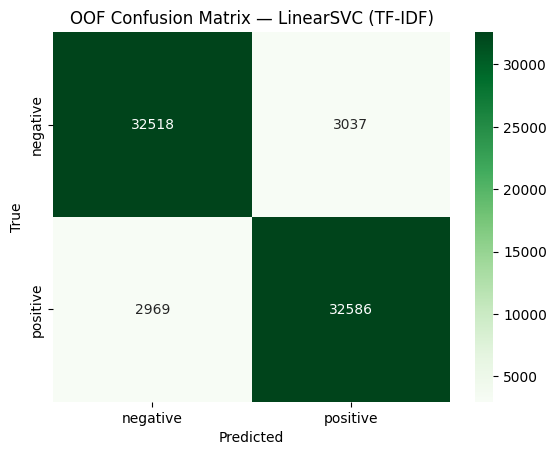

ROC-AUC (positive):  0.9724
PR-AUC  (positive): 0.9722
PR-AUC  (negative): 0.9726


In [ ]:
pipe_svm = make_svm()

oof_pred, oof_score, fold_f1 = get_oof(
    pipe_svm, X, y, cv, score_kind="decision"   # LinearSVC => decision scores
)

print("OOF macro-F1 per fold (from OOF loop):", np.round(fold_f1, 4))
print("OOF macro-F1 mean±std:", np.round(fold_f1.mean(),4), "±", np.round(fold_f1.std(),4))

summary_svm = eval_oof(
    y_true=y, y_pred=oof_pred, y_score=oof_score,
    model_name="LinearSVC (TF-IDF)",
    score_kind="decision",      # eval helper will use -score for PR-AUC(neg)
    cm_cmap="Greens"
)

Hyper-parameter search (lean grid) + results table

In [ ]:
grid_svm = {
    # TF-IDF
    "tfidf__max_features": [10_000, 20_000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "tfidf__strip_accents": ["unicode"],
    "tfidf__token_pattern": [r"(?u)\b[a-zA-Z]{3,}\b"],

    # LinearSVC
    "clf__C": [0.5, 1.0, 2.0],
    # keep stable fixed choices:
    "clf__loss": ["squared_hinge"],
    "clf__penalty": ["l2"],
    "clf__dual": [False],
    "clf__class_weight": ["balanced"],
    "clf__max_iter": [3000],
}

best_svm, best_svm_score, best_svm_params, grid_view_svm = run_grid(
    make_svm(), grid_svm, X, y, cv=cv, verbose=1
)
print("Best CV macro-F1:", round(best_svm_score, 4))
print("Best params:", best_svm_params)
print("\n\n")

show_cols_lr = [
    "mean_test_score","std_test_score","mean_fit_time",
    "param_clf__C",
    "param_tfidf__max_features","param_tfidf__min_df","param_tfidf__ngram_range",
]

display(grid_view_svm[show_cols_lr].head(10))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV macro-F1: 0.9207
Best params: {'clf__C': 0.5, 'clf__class_weight': 'balanced', 'clf__dual': False, 'clf__loss': 'squared_hinge', 'clf__max_iter': 3000, 'clf__penalty': 'l2', 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__strip_accents': 'unicode', 'tfidf__token_pattern': '(?u)\\b[a-zA-Z]{3,}\\b'}





,mean_test_score,std_test_score,mean_fit_time,param_clf__C,param_tfidf__max_features,param_tfidf__min_df,param_tfidf__ngram_range
7,0.920700,0.001817,14.665666,0.5,20000,2,"(1, 2)"
5,0.920602,0.001913,14.930349,0.5,20000,1,"(1, 2)"
3,0.918591,0.002118,14.623990,0.5,10000,2,"(1, 2)"
1,0.918492,0.002109,14.490721,0.5,10000,1,"(1, 2)"
15,0.917002,0.001549,14.892655,1.0,20000,2,"(1, 2)"
13,0.916917,0.001496,14.812333,1.0,20000,1,"(1, 2)"
9,0.915553,0.002031,14.784425,1.0,10000,1,"(1, 2)"
11,0.915427,0.002053,14.660055,1.0,10000,2,"(1, 2)"
4,0.913275,0.000942,4.704125,0.5,20000,1,"(1, 1)"
6,0.913106,0.001152,5.118306,0.5,20000,2,"(1, 1)"


SVM doesn’t output probabilities, we use decision scores for ROC/PR; PR-AUC(neg) is computed with −score.

Save the tuned SVM pipeline

In [ ]:
save_model(best_svm, "linearsvc_tfidf_cv_best.joblib")

Saved: linearsvc_tfidf_cv_best.joblib


---
### 3 – ColumnTransformer model (text + numeric helpers)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Expect df_feat to have: ["Text_clean", "word_count", "text_len", "sentiment"]

#assert all(c in df_feat.columns for c in ["Text_clean","word_count","text_len","sentiment"]), \
#    "df_feat must contain Text_clean, word_count, text_len, sentiment"

# 1) Column names (reuse across this model)
TEXT_COL = "Text_clean"
NUM_COLS = ["word_count", "text_len"]

# 2) Bind features/labels from df_feat
X_ct = df_feat[[TEXT_COL, *NUM_COLS]].copy()
y_ct = df_feat["sentiment"].copy()
print("X_ct columns:", list(X_ct.columns))
print("y_ct distribution:\n", y_ct.value_counts(normalize=True).round(3))

X_ct columns: ['Text_clean', 'word_count', 'text_len']
y_ct distribution:
 sentiment
negative    0.5
positive    0.5
Name: proportion, dtype: float64


In [ ]:
# 3) Factory for the ColumnTransformer + LogisticRegression pipeline
def make_coltx_lr():
    pre = ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(**TFIDF_DEFAULTS), TEXT_COL),
            ("num", StandardScaler(), NUM_COLS),
        ],
        verbose_feature_names_out=False,
        remainder="drop"
    )
    return Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=400,
            n_jobs=1,                 # avoid nested parallelism
            random_state=RANDOM_STATE
        ))
    ])

CV macro-F1 (per-fold + mean±std)

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

pipe_ct_lr = make_coltx_lr()

cv_scores = cross_val_score(
    pipe_ct_lr, X_ct, y_ct, cv=cv, scoring="f1_macro", n_jobs=-1
)
print("CV macro-F1 per fold:", np.round(cv_scores, 4))
print("CV macro-F1 mean±std:", np.round(cv_scores.mean(), 4), "±", np.round(cv_scores.std(), 4))

CV macro-F1 per fold: [0.915  0.9175 0.9172 0.9234 0.9158]
CV macro-F1 mean±std: 0.9178 ± 0.0029


OOF evaluation (report, CM heatmap, ROC-AUC, PR-AUC pos/neg)

OOF macro-F1 per fold (from OOF loop): [0.915  0.9175 0.9172 0.9234 0.9158]
OOF macro-F1 mean±std: 0.9178 ± 0.0029

OOF classification report — ColumnTransformer (TF-IDF text + numeric) + LR

              precision    recall  f1-score   support

    negative     0.9180    0.9175    0.9178     35555
    positive     0.9175    0.9181    0.9178     35555

    accuracy                         0.9178     71110
   macro avg     0.9178    0.9178    0.9178     71110
weighted avg     0.9178    0.9178    0.9178     71110



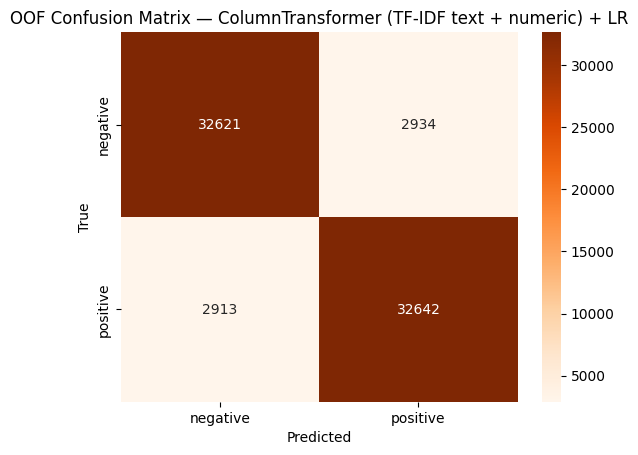

ROC-AUC (positive):  0.9736
PR-AUC  (positive): 0.9733
PR-AUC  (negative): 0.9735


In [ ]:
pipe_ct_lr = make_coltx_lr()

oof_pred, oof_score, fold_f1 = get_oof(
    pipe_ct_lr, X_ct, y_ct, cv, score_kind="proba"   # Logistic → predict_proba
)

print("OOF macro-F1 per fold (from OOF loop):", np.round(fold_f1, 4))
print("OOF macro-F1 mean±std:", np.round(fold_f1.mean(),4), "±", np.round(fold_f1.std(),4))

summary_ct = eval_oof(
    y_true=y_ct, y_pred=oof_pred, y_score=oof_score,
    model_name="ColumnTransformer (TF-IDF text + numeric) + LR",
    score_kind="proba",
    cm_cmap="Oranges"
)

Hyper-parameter search (lean) + results table

In [ ]:
grid_ct = {
    # Text branch (note path through ColumnTransformer)
    "pre__text__max_features": [10_000, 20_000],
    "pre__text__ngram_range": [(1,1), (1,2)],
    "pre__text__min_df": [1, 2],
    "pre__text__strip_accents": ["unicode"],
    "pre__text__token_pattern": [r"(?u)\b[a-zA-Z]{3,}\b"],

    # Classifier
    "clf__C": [0.5, 1.0, 2.0],
    "clf__solver": ["saga"],
    "clf__n_jobs": [1],
}

best_ct, best_ct_score, best_ct_params, grid_view_ct = run_grid(
    make_coltx_lr(), grid_ct, X_ct, y_ct, cv=cv, verbose=1
)
print("Best CV macro-F1:", round(best_ct_score, 4))
print("Best params:", best_ct_params)
print("\n\n")

show_cols_ct = [
    "mean_test_score","std_test_score","mean_fit_time",
    "param_clf__C",
    "param_pre__text__max_features","param_pre__text__min_df","param_pre__text__ngram_range",
]
display(grid_view_ct[show_cols_ct].head(10))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV macro-F1: 0.9201
Best params: {'clf__C': 2.0, 'clf__n_jobs': 1, 'clf__solver': 'saga', 'pre__text__max_features': 20000, 'pre__text__min_df': 2, 'pre__text__ngram_range': (1, 2), 'pre__text__strip_accents': 'unicode', 'pre__text__token_pattern': '(?u)\\b[a-zA-Z]{3,}\\b'}





/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,mean_test_score,std_test_score,mean_fit_time,param_clf__C,param_pre__text__max_features,param_pre__text__min_df,param_pre__text__ngram_range
23,0.920067,0.002654,52.881023,2.0,20000,2,"(1, 2)"
21,0.919927,0.002687,58.734189,2.0,20000,1,"(1, 2)"
19,0.919111,0.002964,50.799004,2.0,10000,2,"(1, 2)"
17,0.919055,0.002843,51.655685,2.0,10000,1,"(1, 2)"
15,0.917550,0.002464,50.083073,1.0,20000,2,"(1, 2)"
13,0.917508,0.002405,49.766316,1.0,20000,1,"(1, 2)"
11,0.917170,0.002706,47.216721,1.0,10000,2,"(1, 2)"
9,0.917044,0.002653,47.196249,1.0,10000,1,"(1, 2)"
20,0.913823,0.002048,42.058543,2.0,20000,1,"(1, 1)"
22,0.913809,0.002047,41.778200,2.0,20000,2,"(1, 1)"


Save the tuned ColumnTransformer pipeline

In [ ]:
save_model(best_ct, "coltx_tfidf_num_logreg_cv_best.joblib")

Saved: coltx_tfidf_num_logreg_cv_best.joblib


---
### 4 – TF-IDF → TruncatedSVD (≈300) → MLPClassifier (scikit-learn)

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

MLP doesn’t support class_weight=; we use sample weights in every fit.

In [ ]:
# ===== Data & weights for MLP =====
X_mlp = df["Text_clean"]
y_mlp = df["sentiment"]

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

CLASSES = np.array(["negative","positive"])
CLASS_WEIGHT = compute_class_weight(class_weight="balanced", classes=CLASSES, y=y_mlp)
W_MAP = dict(zip(CLASSES, CLASS_WEIGHT))
SAMPLE_WEIGHTS = y_mlp.map(W_MAP).values  # 1D array aligned with y_mlp

print("Class weights:", W_MAP)
print("y distribution:\n", y_mlp.value_counts(normalize=True).round(3))

Class weights: {np.str_('negative'): np.float64(1.0), np.str_('positive'): np.float64(1.0)}
y distribution:
 sentiment
negative    0.5
positive    0.5
Name: proportion, dtype: float64


Model factory (TF-IDF → SVD → Scaler → MLP)

In [ ]:
def make_mlp(n_components=300, hls=(256, 64), alpha=1e-4, sampling_strategy=1.0):
    """
    TF-IDF -> SVD -> Scaler -> RandomUnderSampler -> MLP (no early_stopping to avoid dtype issues)
    """
    return ImbPipeline([
        ("tfidf",  TfidfVectorizer(**TFIDF_DEFAULTS)),
        ("svd",    TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)),
        ("scaler", StandardScaler(with_mean=True)),
        ("sampler", RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)),
        ("clf",    MLPClassifier(
            hidden_layer_sizes=hls,
            activation="relu",
            alpha=alpha,                 # L2 regularization
            learning_rate_init=1e-3,
            early_stopping=False,        # <-- changed
            max_iter=150,                # a bit higher since no early stopping
            n_iter_no_change=10,         # harmless if early_stopping=False
            random_state=RANDOM_STATE
        ))
    ])
    ## add more layers


CV macro-F1 (per-fold + mean±std)

In [ ]:
pipe_mlp = make_mlp(n_components=300, hls=(256, 64), alpha=1e-4, sampling_strategy=1.0) # two hidden layers 256, 64

oof_pred_mlp, oof_score_mlp, fold_f1_mlp = get_oof(
    estimator=pipe_mlp,
    X=X_mlp, y=y_mlp,
    cv=cv,
    score_kind="proba"   # MLP has predict_proba
)

print("CV macro-F1 per fold:", np.round(fold_f1_mlp, 4))
print("CV macro-F1 mean±std:", np.round(fold_f1_mlp.mean(), 4), "±", np.round(fold_f1_mlp.std(), 4))

CV macro-F1 per fold: [0.8822 0.8877 0.8779 0.8845 0.8798]
CV macro-F1 mean±std: 0.8824 ± 0.0035


OOF evaluation (report, CM heatmap, ROC-AUC, PR-AUC pos/neg)


OOF classification report — TF-IDF → SVD → MLP

              precision    recall  f1-score   support

    negative     0.8855    0.8784    0.8819     35555
    positive     0.8794    0.8864    0.8829     35555

    accuracy                         0.8824     71110
   macro avg     0.8824    0.8824    0.8824     71110
weighted avg     0.8824    0.8824    0.8824     71110



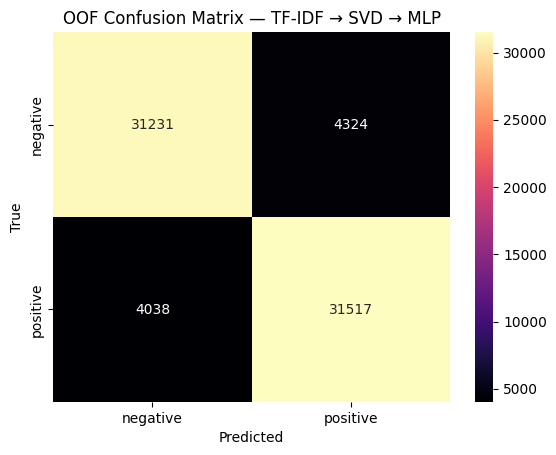

ROC-AUC (positive):  0.9518
PR-AUC  (positive): 0.9506
PR-AUC  (negative): 0.9522


In [ ]:
summary_mlp = eval_oof(
    y_true=y_mlp, y_pred=oof_pred_mlp, y_score=oof_score_mlp,
    model_name="TF-IDF → SVD → MLP",
    score_kind="proba",
    cm_cmap="magma"
)

Grid search (no weights needed; sampler handles imbalance)

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv_grid_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # faster for grids

grid_mlp = {
    # TF-IDF (keep fixed-ish to limit search time; still safe)
    "tfidf__max_features": [20_000],
    "tfidf__ngram_range": [(1,2)],
    "tfidf__min_df": [1],   # safer on small folds
    "tfidf__strip_accents": ["unicode"],
    "tfidf__token_pattern": [r"(?u)\b[a-zA-Z]{3,}\b"],

    # SVD dimensionality
    "svd__n_components": [200, 300, 400],

    # Sampler (imbalance control)
    "sampler__sampling_strategy": [1.0],  # 1:1 in each training fold

    # MLP
    "clf__hidden_layer_sizes": [(256,), (256,64), (256,128)],
    "clf__alpha": [1e-4, 1e-3],
    "clf__learning_rate_init": [1e-3],
    "clf__max_iter": [150],
}

best_mlp, best_mlp_score, best_mlp_params, grid_view_mlp = run_grid(
    make_mlp(), grid_mlp, X_mlp, y_mlp,
    cv=cv_grid_fast,   # faster during search; you still report 5-fold OOF
    verbose=1
)
print("Best CV macro-F1 (3-fold):", round(best_mlp_score, 4))
print("Best params:", best_mlp_params)
print("\n\n")

show_cols_mlp = [
    "mean_test_score","std_test_score","mean_fit_time",
    "param_svd__n_components",
    "param_clf__hidden_layer_sizes","param_clf__alpha",
    "param_tfidf__max_features","param_tfidf__min_df","param_tfidf__ngram_range",
    # "param_sampler__sampling_strategy",  # include if you tuned it
]
display(grid_view_mlp[show_cols_mlp].head(10))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best CV macro-F1 (3-fold): 0.8941
Best params: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (256,), 'clf__learning_rate_init': 0.001, 'clf__max_iter': 150, 'sampler__sampling_strategy': 1.0, 'svd__n_components': 400, 'tfidf__max_features': 20000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__strip_accents': 'unicode', 'tfidf__token_pattern': '(?u)\\b[a-zA-Z]{3,}\\b'}





,mean_test_score,std_test_score,mean_fit_time,param_svd__n_components,param_clf__hidden_layer_sizes,param_clf__alpha,param_tfidf__max_features,param_tfidf__min_df,param_tfidf__ngram_range
11,0.894051,0.000494,168.467957,400,"(256,)",0.0010,20000,1,"(1, 2)"
2,0.893613,0.001091,163.893284,400,"(256,)",0.0001,20000,1,"(1, 2)"
1,0.888609,0.001185,159.548892,300,"(256,)",0.0001,20000,1,"(1, 2)"
10,0.888412,0.001492,134.368320,300,"(256,)",0.0010,20000,1,"(1, 2)"
5,0.887549,0.005665,185.720198,400,"(256, 64)",0.0001,20000,1,"(1, 2)"
14,0.886390,0.005077,178.366917,400,"(256, 64)",0.0010,20000,1,"(1, 2)"
7,0.885115,0.002743,202.779069,300,"(256, 128)",0.0001,20000,1,"(1, 2)"
4,0.884516,0.002610,150.101136,300,"(256, 64)",0.0001,20000,1,"(1, 2)"
16,0.884107,0.004804,155.870619,300,"(256, 128)",0.0010,20000,1,"(1, 2)"
13,0.883827,0.002499,147.409069,300,"(256, 64)",0.0010,20000,1,"(1, 2)"


Save the tuned MLP pipeline

In [ ]:
save_model(best_mlp, "tfidf_svd_mlp_cv_best.joblib")

Saved: tfidf_svd_mlp_cv_best.joblib


# Selecting Best Model

| Model                                       | Macro-F1   |
| ------------------------------------------- | ---------- |
| **Logistic Regression (TF-IDF)**            | **0.9181** |
| **ColumnTransformer + Logistic Regression** | **0.9178** |
| **LinearSVM (TF-IDF)**                      | **0.9155** |
| **MLP (SVD → MLP)**                         | **0.8824** |


In [40]:
from google.colab import files
files.download("logreg_tfidf_cv_best.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>